<a href="https://colab.research.google.com/github/Nitish-9k/AI-REALTIME-GYM-COACH-MEDIAPIPE-LLAMA/blob/main/JupyterNotebook/EDA%26DATAPREP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv("resumeJD_pairs (1).csv")
df.shape

(320, 4)

In [ ]:
print("dataset info")
df.info()




dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      318 non-null    object 
 1   job_description  316 non-null    object 
 2   match_score      320 non-null    float64
 3   match_label      320 non-null    object 
dtypes: float64(1), object(3)
memory usage: 10.1+ KB


In [ ]:

df.describe()

,match_score
count,320.000000
mean,0.863406
std,5.514443
min,-0.200000
25%,0.140000
50%,0.540000
75%,0.890000
max,99.000000


In [ ]:
print(f"columnsf{list[df.columns]}")
df.head()

columnsflist[Index(['resume_text', 'job_description', 'match_score', 'match_label'], dtype='object')]


,resume_text,job_description,match_score,match_label
0,Operations Analyst with 12 years of experience...,Network Engineer at nonprofit organization. Re...,0.16,low
1,Cybersecurity Analyst with 7 years of experien...,Financial Analyst at financial institution. Re...,0.08,low
2,Supply Chain Analyst with 8 years of experienc...,Registered Nurse at financial institution. Req...,0.91,HIGH
3,Registered Nurse with 2 years of experience sp...,Business Intelligence Analyst at e-commerce co...,0.11,low
4,Financial Analyst with 9 years of experience s...,Recruiter at nonprofit organization. Required ...,0.07,low


In [ ]:
print("text column summary")
df.describe(include=object)

text column summary


,resume_text,job_description,match_label
count,318,316,320
unique,316,312,6
top,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,high
freq,3,3,125


In [ ]:
print("missing value")
missing=df.isnull().sum()
missing_pct=(missing/len(df))*100
missing_df=pd.DataFrame({
    "missing_count":missing,
    "Percentage":missing_pct
})
print(missing_df)
print(f"total missing values:{missing.sum()}")


missing value
                 missing_count  Percentage
resume_text                  2       0.625
job_description              4       1.250
match_score                  0       0.000
match_label                  0       0.000
total missing values:6


In [ ]:
print("duplicates")
full_dupes=df.duplicated().sum()
print(f"full duplicates {full_dupes}")


duplicates
full duplicates 2


In [ ]:
pair_dupes=df.duplicated(subset=["resume_text","job_description"]).sum()
print(f"duplicate of resume and jd pairs {pair_dupes}")

duplicate of resume and jd pairs 2


In [ ]:
print("duplicate rows")
df[df.duplicated(subset=["resume_text","job_description"],keep=False)]


duplicate rows


,resume_text,job_description,match_score,match_label
220,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,0.91,high
230,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,0.91,high
260,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,0.91,high


In [ ]:
#what label exists
print("unique label")
print(df["match_label"].value_counts())

print(f"expected 3 labels but got {df["match_label"].nunique()}")
print("disticnt values")
print(df["match_label"].unique())


unique label
match_label
high      125
medium     98
low        93
HIGH        2
High        1
MEDIUM      1
Name: count, dtype: int64
expected 3 labels but got 6
disticnt values
['low' 'HIGH' 'high' 'medium' 'High' 'MEDIUM']


In [ ]:
print(f"total rows:           {len(df)}")
print(f"unique resume         {df['resume_text'].nunique()} ")
print(f"Unique JDs:           {df["job_description"].nunique()}")
print(f"Unique pairs          {df[["resume_text","job_description"]].drop_duplicates().shape[0]}")

total rows:           320
unique resume         316 
Unique JDs:           312
Unique pairs          318


In [ ]:
print("score distribution")
print(df["match_score"].describe())


print("invalid score")
invalid_score=df[(df["match_score"]<0.0) | (df["match_score"]>1)]
print(f"invalid score {len(invalid_score)}")
print(invalid_score[["match_label","match_score"]])

score distribution
count    320.000000
mean       0.863406
std        5.514443
min       -0.200000
25%        0.140000
50%        0.540000
75%        0.890000
max       99.000000
Name: match_score, dtype: float64
invalid score
invalid score 6
    match_label  match_score
247      medium         2.30
261        high         1.50
262        high        -0.20
266         low        99.00
309        high         1.20
319        high        -0.05


In [ ]:
print("score stats per label(after lowercasing)")
df["match_lower_label"]=df["match_label"].str.lower()
df.groupby('match_lower_label')["match_score"].describe()

score stats per label(after lowercasing)


,count,mean,std,min,25%,50%,75%,max
match_lower_label,,,,,,,,
high,128.0,0.880391,0.171806,-0.20,0.88,0.90,0.930,1.5
low,93.0,1.188280,10.253673,0.05,0.08,0.10,0.130,99.0
medium,99.0,0.536263,0.192224,0.40,0.48,0.52,0.555,2.3


In [ ]:
print("Null Values")
nulls=df[df.isnull().any(axis=1)]
print(f"rows with at least one null {len(nulls)}")
nulls[["match_label","match_score"]]

Null Values
rows with at least one null 6


,match_label,match_score
42,medium,0.55
54,low,0.10
79,low,0.05
208,medium,0.49
217,medium,0.52
257,medium,0.50


In [ ]:
print("="*50)
print("data quality report")
print("="*50)
print(f"Total rows:            {len(df)}")
print(f"full duplicates        {df .duplicated().sum()}")
print(f"duplicate pairs        {df.duplicated(subset=("resume_text","job_description")).sum()}")
print(f"Null resume_text       {df["resume_text"].isnull().sum()}")
print(f"Null job_description:  {df["job_description"].isnull().sum()}")
print(f"Label Case Variant:    {df["match_label"].nunique()}")
print(f"Invalid_score          {((df['match_score']<0)|(df["match_score"]>1)).sum()}")




data quality report
Total rows:            320
full duplicates        2
duplicate pairs        2
Null resume_text       2
Null job_description:  4
Label Case Variant:    6
Invalid_score          6


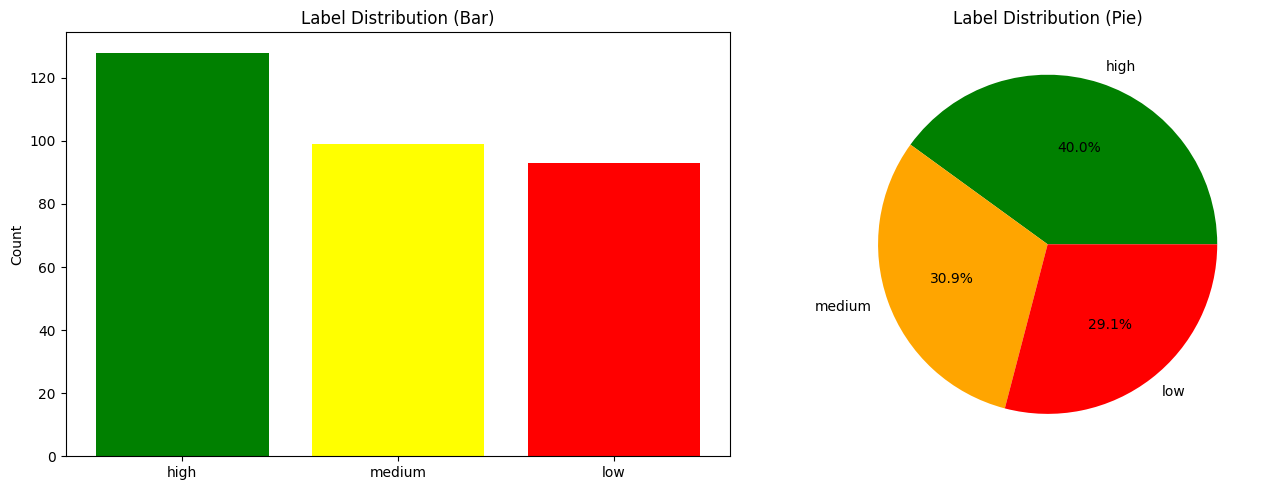

In [ ]:
#visulaization
fig,axes=plt.subplots(1,2 ,figsize=(14,5))
counts=df["match_label"].str.lower().value_counts()
axes[0].bar(counts.index,counts.values,color=["green","yellow","red"])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()


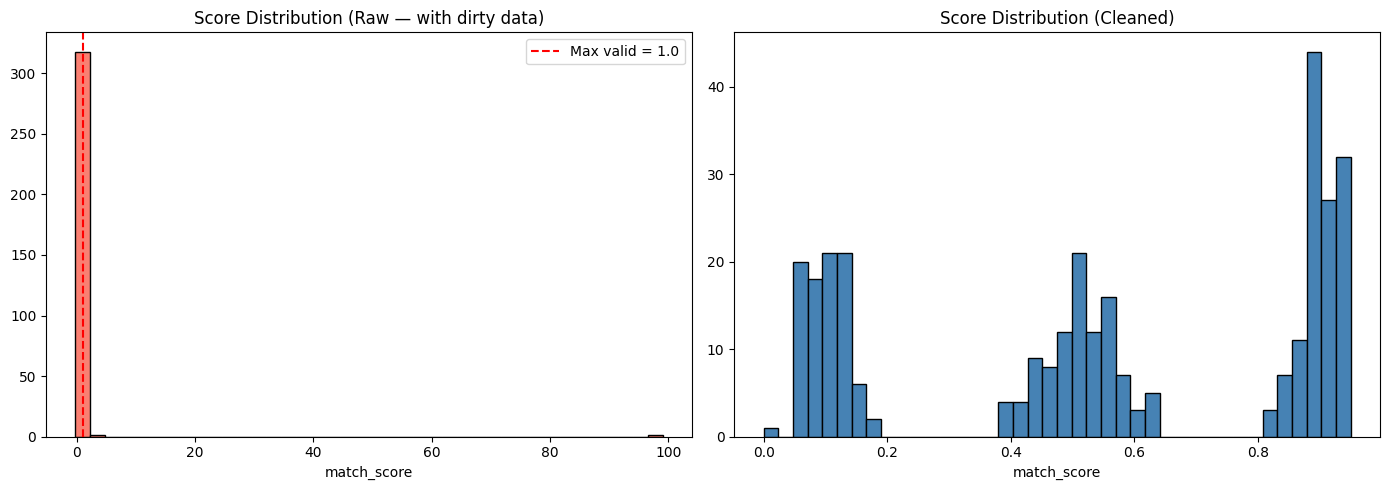

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1074/2827367188.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='match_label', y='match_score',


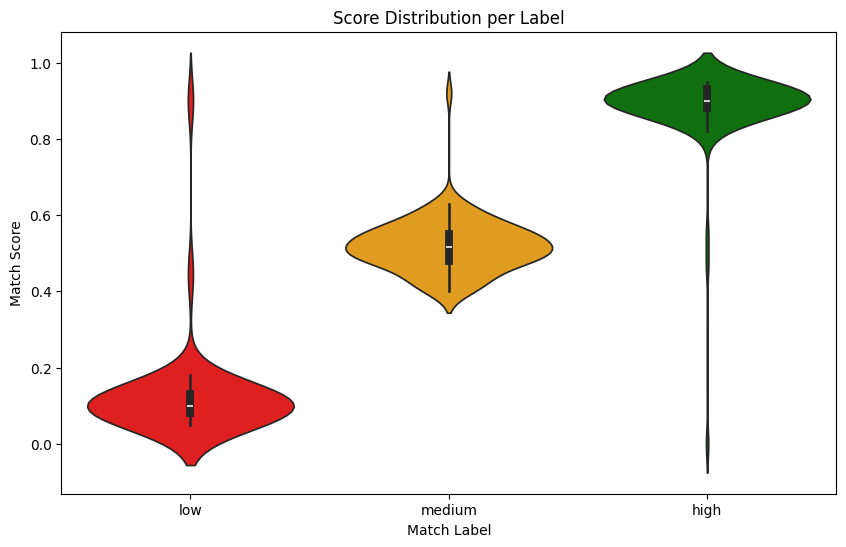

In [ ]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()



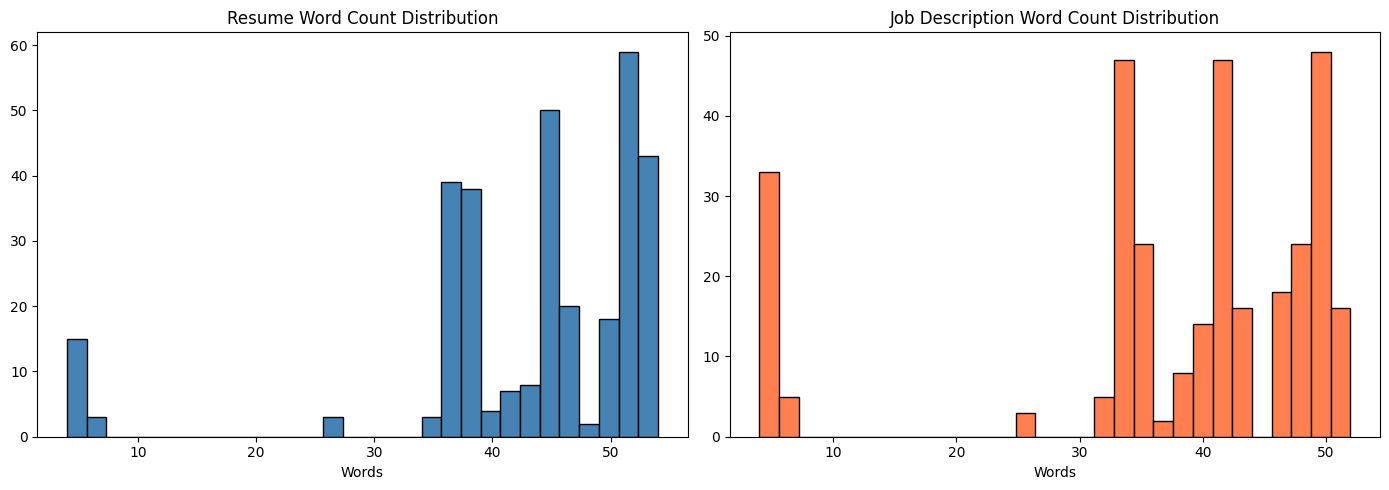

In [ ]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

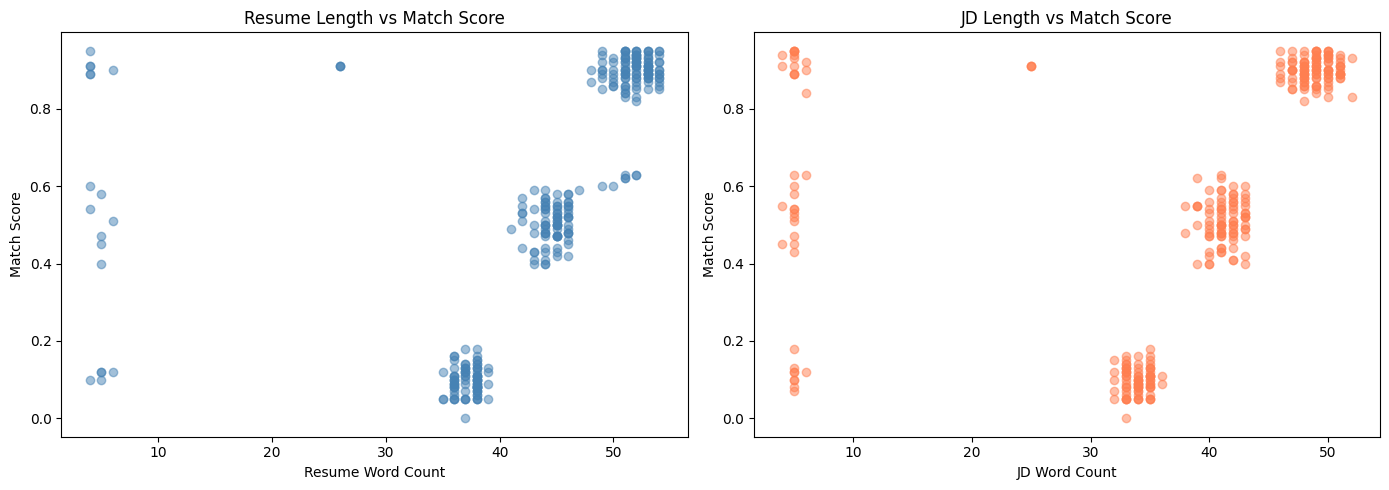

Resume length correlation: 0.486
JD length correlation:     0.347


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))


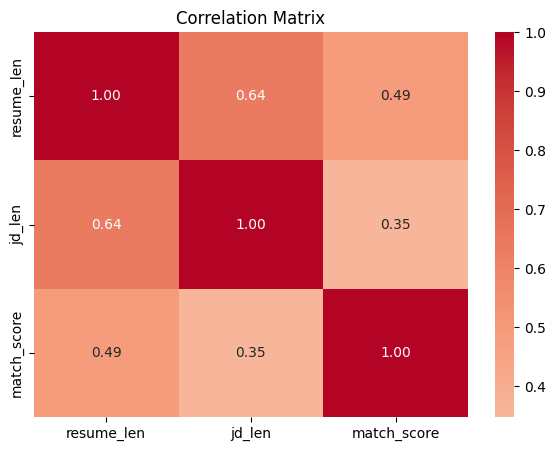

In [ ]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:

pip install wordcloud


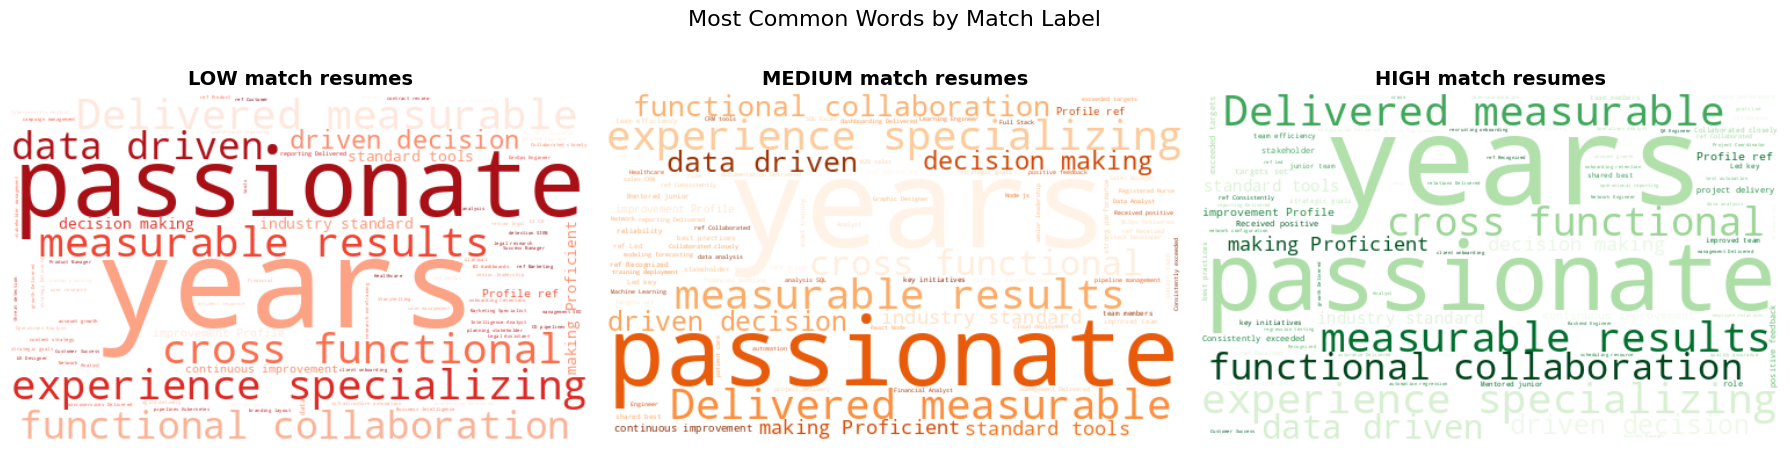

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Always record the starting point so that you  can see what changed
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

BEFORE CLEANING
Total rows:       320
Null resume_text: 2
Null job_desc:    4
Duplicates:       2
Label variants:   6
Invalid scores:   6


In [ ]:
df_clean=df.copy()
#problem of inconsistency

print("before:", df_clean["match_label"].value_counts().to_dict())

df["match_label"]=df_clean["match_label"].str.lower().str.strip()
print("After:", df_clean["match_label"].value_counts().to_dict())


before: {'high': 128, 'medium': 99, 'low': 93}
After: {'high': 128, 'medium': 99, 'low': 93}


In [ ]:
print(f"before dropping null values : {len(df_clean)}")
df_clean=df_clean.dropna(subset=["resume_text","job_description"])
print(f"after dropping null values : {len(df_clean)}")

before dropping null values : 320
after dropping null values : 314


In [ ]:

print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 314 rows
Duplicate pairs found: 2
After removing duplicates:  312 rows


In [ ]:
invalid_mask=(df_clean["match_score"]<0.0)|(df_clean["match_score"]>1)
print(f"invalid score found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")



invalid score found: 6
    match_label  match_score
247      medium         2.30
261        high         1.50
262        high        -0.20
266         low        99.00
309        high         1.20
319        high        -0.05

Rows after removing invalid scores: 306


In [ ]:

#are the scores consistent with what the label claims?
# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['match_label','match_score']]

Score range per label:
              min   max  mean
match_label                  
high         0.00  0.95  0.89
low          0.05  0.92  0.13
medium       0.40  0.92  0.52

Label-score mismatches: 8


,match_label,match_score
225,medium,0.92
232,high,0.00
245,low,0.47
250,low,0.42
263,low,0.92
265,high,0.47
307,low,0.88
311,high,0.55


In [ ]:

# A 15-character resume or JD is useless for training
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']     = df_clean['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")


Short texts found:
  resume_text < 20 words: 18
  job_description < 10 words: 38

Rows after removing short texts: 266


In [ ]:

df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        320
  Final rows:           266
  Rows removed:         54

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.0 – 0.95

Label distribution after cleaning:
match_label
high      107
low        81
medium     78
Name: count, dtype: int64


In [ ]:
# Drop the helper columns we added during EDA
df_clean.to_csv('cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved:cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved:cleaned_resumeJD_pairs.csv (266 rows)
